# FCNN — Rede Neural Totalmente Conectada

Rede neural profunda (096 \to 2048 \to 1024 \to 516 \to 2$) utilizando **concatenação de múltiplos embeddings por conversa**.
Utiliza **Adam** com **Weight Decay (L2)** para regularização e Early Stopping para salvar o melhor checkpoint.

In [1]:
import sys, os

# Localiza e adiciona o diretório 'backend' ao sys.path
notebook_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else os.getcwd()
backend_dir = os.path.abspath(os.path.join(notebook_dir, '..')) if os.path.basename(notebook_dir) == 'notebooks' else notebook_dir
if not os.path.exists(os.path.join(backend_dir, 'machine_learning')):
    backend_dir = '/home/andrei.pinto/HorusEmbbedingPlusML/backend'

if backend_dir not in sys.path:
    sys.path.insert(0, backend_dir)

os.chdir(backend_dir)

from machine_learning import (
    train_fcnn, learning_curve_fcnn, evaluate_fcnn_cross_turns, grid_search_fcnn,
    ThresholdCalibrator, load_concat_embeddings,
)

# Utiliza a combinação voyage + openai (4096d) que obteve 100% de Acurácia e Recall no estudo de backup
EMBEDDERS = ["voyage", "openai"]
WITH_AUGMENTED = True


## 1. Cenário 1: Treino em Turnos Completos ()
Treinamento da FCNN com dados aumentados () considerando toda a sequência da conversa.

In [2]:
# Treina/Carrega FCNN no cenário 1 (all_data) com voyage + openai
res_all = train_fcnn(
    path_data="all_data",
    embedders=EMBEDDERS,
    with_augmented=WITH_AUGMENTED,
    epochs=20,
    lr=1e-3,
    batch_size=200,
    weight_decay=1e-3,
    patience=10,
    seed=42,
    force_retrain=False
)


[fcnn] Cache hit: carregando FCNN existente
[data] Concatenando 2 embeddings: ['voyage', 'openai']
  [data] voyage: voyage_chunks.parquet
    Shape: (9648, 1024)
  [data] openai: openai_chunks.parquet
    Shape: (9648, 3072)
[data] Shape final concatenado: X=(9648, 4096), y=(9648,)
[cache] Carregando FCNN: experiment_results/fcnn/augmented__all_data/model.pth


/home/andrei.pinto/HorusEmbbedingPlusML/backend/machine_learning/cache.py:132: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location="cpu")


  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/fcnn/batch_size=200__embedders=voyage_openai__epochs=20__lr=0.001__path_dat_bddd81d9/learning_curves.png


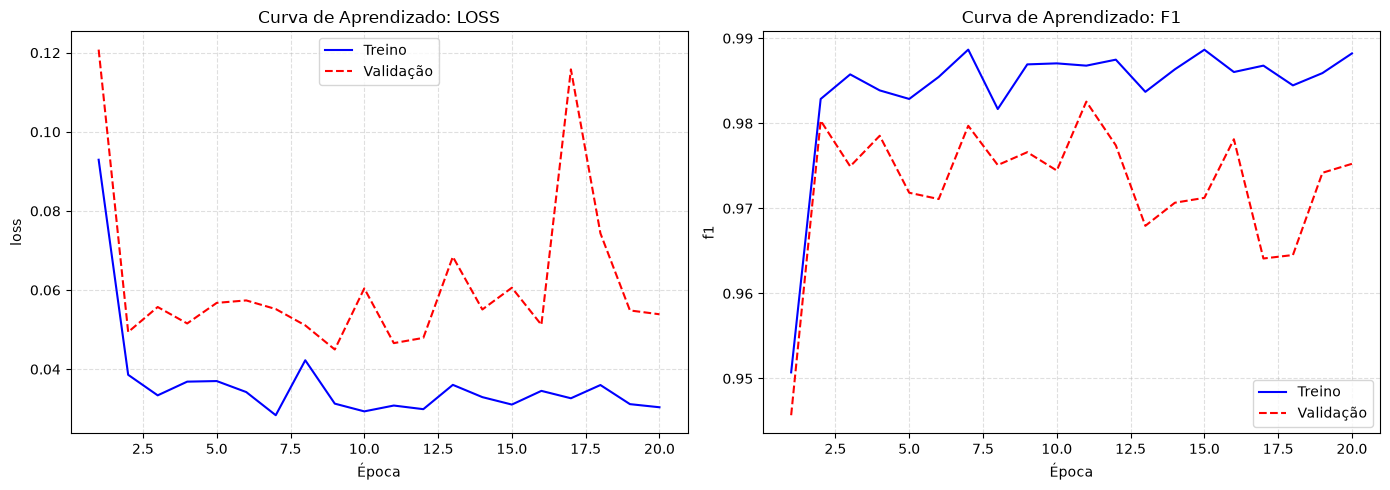

In [3]:
# Curvas de Aprendizado por Época (Train vs Val Loss e F1-Score)
res_all.plot_learning_curves()


  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/fcnn/batch_size=200__embedders=voyage_openai__epochs=20__lr=0.001__path_dat_bddd81d9/confusion_matrix.png


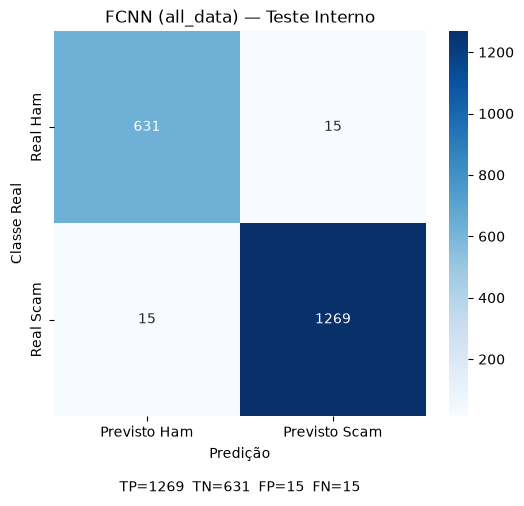

              precision    recall  f1-score   support

     Ham (0)       0.98      0.98      0.98       646
    Scam (1)       0.99      0.99      0.99      1284

    accuracy                           0.98      1930
   macro avg       0.98      0.98      0.98      1930
weighted avg       0.98      0.98      0.98      1930



In [4]:
# Desempenho no Teste Interno
res_all.plot_confusion_matrix(title="FCNN (all_data) — Teste Interno")
res_all.print_classification_report()


[data] Concatenando 2 embeddings: ['voyage', 'openai']
  [data] voyage: voyage_chunks.parquet
    Shape: (1083, 1024)
  [data] openai: openai_chunks.parquet
    Shape: (1083, 3072)
[data] Shape final concatenado: X=(1083, 4096), y=(1083,)
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/fcnn/batch_size=200__embedders=voyage_openai__epochs=20__lr=0.001__path_dat_bddd81d9/confusion_matrix.png


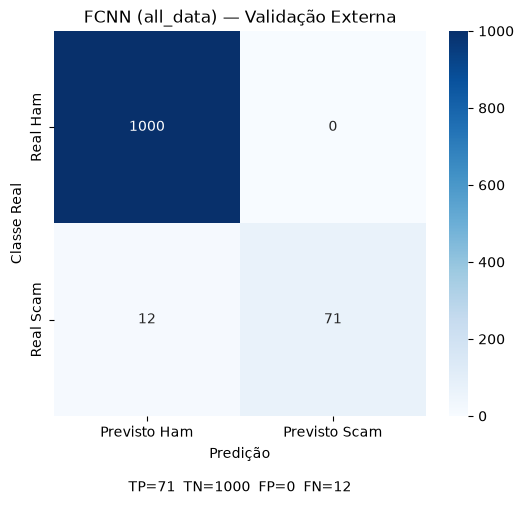

              precision    recall  f1-score   support

     Ham (0)       0.99      1.00      0.99      1000
    Scam (1)       1.00      0.86      0.92        83

    accuracy                           0.99      1083
   macro avg       0.99      0.93      0.96      1083
weighted avg       0.99      0.99      0.99      1083



In [5]:
# Avaliação na Validação Externa
val_all = res_all.evaluate_on_validation()
val_all.plot_confusion_matrix(title="FCNN (all_data) — Validação Externa")
val_all.print_classification_report()


## 2. Cenário 2: Treino em Turnos do Suspeito ()
Treinamento da FCNN com dados aumentados () considerando apenas os turnos enviados pelo suspeito.

In [ ]:
# Treina FCNN no cenário 2 (suspect_turns)
res_suspect = train_fcnn(
    path_data="suspect_turns",
    embedders=EMBEDDERS,
    with_augmented=WITH_AUGMENTED,
    epochs=50,
    lr=1e-5,
    batch_size=200,
    patience=10,
    force_retrain=True
)


[fcnn] Cache hit: carregando FCNN existente
[data] Concatenando 2 embeddings: ['voyage', 'openai']
  [data] voyage: voyage_chunks.parquet
    Shape: (9648, 1024)
  [data] openai: openai_chunks.parquet
    Shape: (9648, 3072)
[data] Shape final concatenado: X=(9648, 4096), y=(9648,)
[cache] Carregando FCNN: experiment_results/fcnn/augmented__suspect_turns/model.pth


/home/andrei.pinto/HorusEmbbedingPlusML/backend/machine_learning/cache.py:132: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location="cpu")


In [7]:
# Curvas de Aprendizado por Época
res_suspect.plot_learning_curves()


Sem histórico de épocas disponível.


  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/fcnn/batch_size=200__embedders=voyage_openai__epochs=50__lr=1e-05__path_dat_60ff972a/confusion_matrix.png


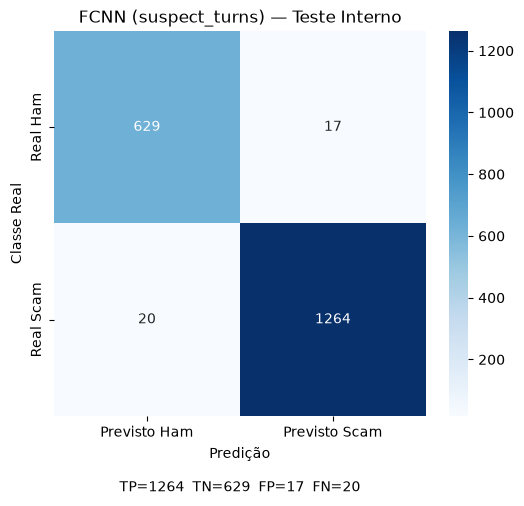

              precision    recall  f1-score   support

     Ham (0)       0.97      0.97      0.97       646
    Scam (1)       0.99      0.98      0.99      1284

    accuracy                           0.98      1930
   macro avg       0.98      0.98      0.98      1930
weighted avg       0.98      0.98      0.98      1930



In [8]:
# Desempenho no Teste Interno
res_suspect.plot_confusion_matrix(title="FCNN (suspect_turns) — Teste Interno")
res_suspect.print_classification_report()


[data] Concatenando 2 embeddings: ['voyage', 'openai']
  [data] voyage: voyage_chunks.parquet
    Shape: (1083, 1024)
  [data] openai: openai_chunks.parquet
    Shape: (1083, 3072)
[data] Shape final concatenado: X=(1083, 4096), y=(1083,)
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/fcnn/batch_size=200__embedders=voyage_openai__epochs=50__lr=1e-05__path_dat_60ff972a/confusion_matrix.png


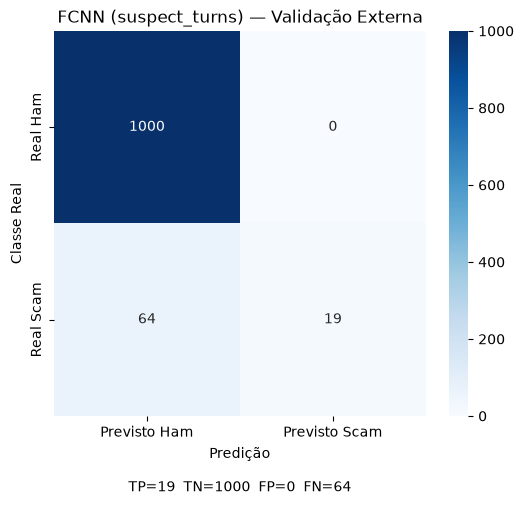

              precision    recall  f1-score   support

     Ham (0)       0.94      1.00      0.97      1000
    Scam (1)       1.00      0.23      0.37        83

    accuracy                           0.94      1083
   macro avg       0.97      0.61      0.67      1083
weighted avg       0.94      0.94      0.92      1083



In [9]:
# Avaliação na Validação Externa
val_suspect = res_suspect.evaluate_on_validation(path_data="suspect_turns")
val_suspect.plot_confusion_matrix(title="FCNN (suspect_turns) — Validação Externa")
val_suspect.print_classification_report()


## 3. Experimento Especial de Transferência Cross-Turno ()
**Pergunta de Pesquisa:** Modelos treinados com conversas completas () conseguem classificar diálogos contendo apenas os turnos do Suspeito ()?


[fcnn] Avaliação Cross-Turns: testando em suspect_turns | dataset=test_internal | augmented=True
[data] Concatenando 2 embeddings: ['voyage', 'openai']
  [data] voyage: voyage_chunks.parquet
    Shape: (9648, 1024)
  [data] openai: openai_chunks.parquet
    Shape: (9648, 3072)
[data] Shape final concatenado: X=(9648, 4096), y=(9648,)
  [fcnn_cross] acc=0.9865  f1_macro=0.9848  f1_scam=0.9899


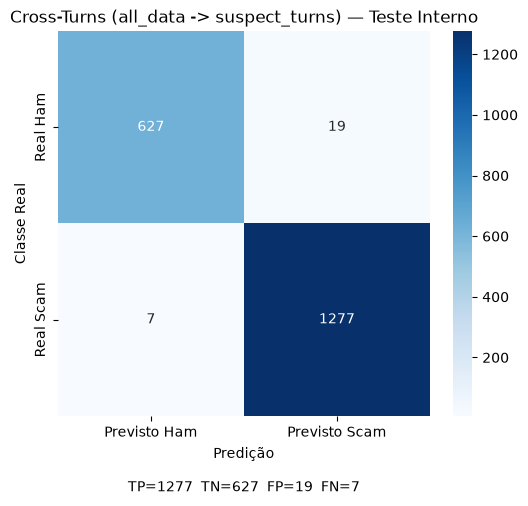

              precision    recall  f1-score   support

     Ham (0)       0.99      0.97      0.98       646
    Scam (1)       0.99      0.99      0.99      1284

    accuracy                           0.99      1930
   macro avg       0.99      0.98      0.98      1930
weighted avg       0.99      0.99      0.99      1930



In [10]:
# Avalia modelo treinado em all_data sobre o Teste Interno de suspect_turns
cross_test = evaluate_fcnn_cross_turns(
    res_all.model,
    path_data="suspect_turns",
    dataset_name="test_internal",
    embedders=EMBEDDERS,
    with_augmented=WITH_AUGMENTED
)
cross_test.plot_confusion_matrix(title="Cross-Turns (all_data -> suspect_turns) — Teste Interno")
cross_test.print_classification_report()



[fcnn] Avaliação Cross-Turns: testando em suspect_turns | dataset=validation | augmented=False
[data] Concatenando 2 embeddings: ['voyage', 'openai']
  [data] voyage: voyage_chunks.parquet
    Shape: (1083, 1024)
  [data] openai: openai_chunks.parquet
    Shape: (1083, 3072)
[data] Shape final concatenado: X=(1083, 4096), y=(1083,)
  [fcnn_cross] acc=0.9631  f1_macro=0.8315  f1_scam=0.6825


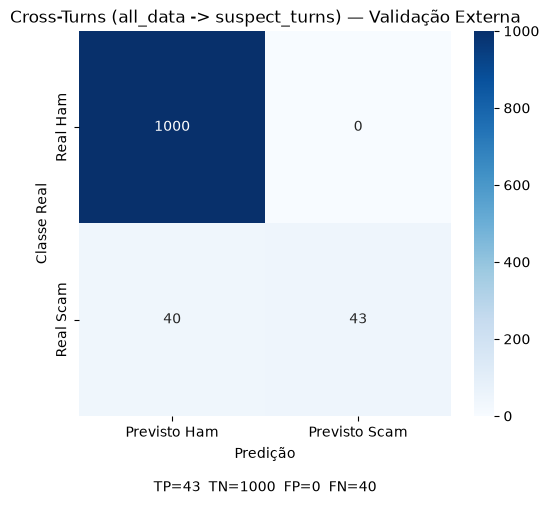

              precision    recall  f1-score   support

     Ham (0)       0.96      1.00      0.98      1000
    Scam (1)       1.00      0.52      0.68        83

    accuracy                           0.96      1083
   macro avg       0.98      0.76      0.83      1083
weighted avg       0.96      0.96      0.96      1083



In [11]:
# Avalia modelo treinado em all_data sobre a Validação Externa de suspect_turns
cross_val = evaluate_fcnn_cross_turns(
    res_all.model,
    path_data="suspect_turns",
    dataset_name="validation",
    embedders=EMBEDDERS,
    with_augmented=False
)
cross_val.plot_confusion_matrix(title="Cross-Turns (all_data -> suspect_turns) — Validação Externa")
cross_val.print_classification_report()


## 4. Calibração de Threshold para Zerar Falsos Negativos (=0$)
Estratégia do backup: Ajusta o threshold no Teste Interno para zerar Falsos Negativos (100% Recall na classe Scam) e aplica a calibração na Validação Externa.

=== Calibração de Threshold (Zero-FN) para FCNN (all_data) ===
[ThresholdCalibrator] Estratégia='min_fn' -> threshold=0.021340


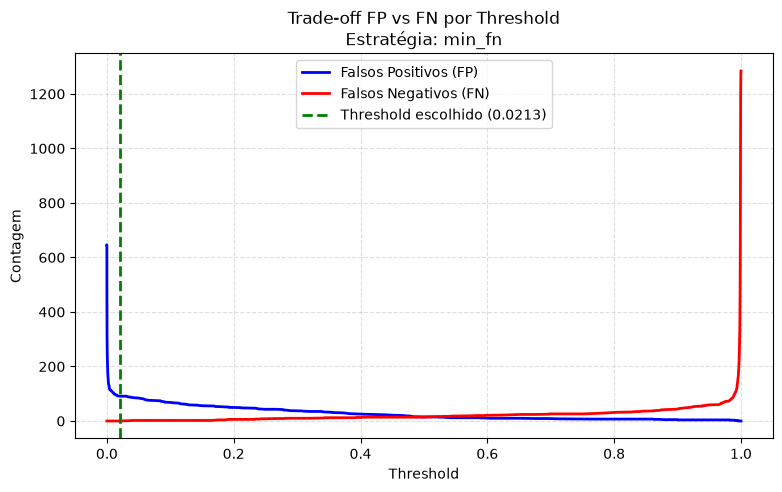

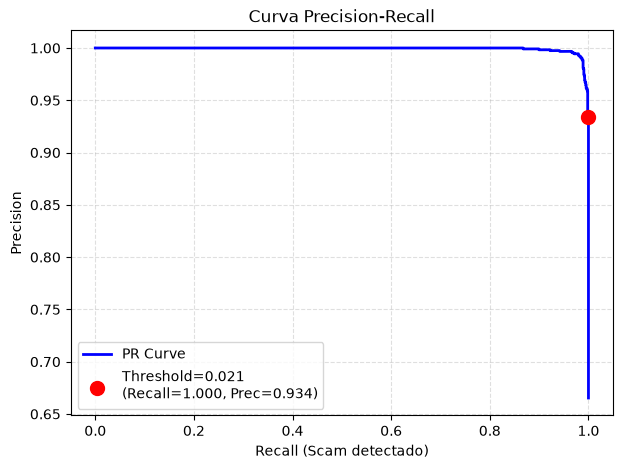

Threshold Calibrado no Teste Interno (Zero-FN): 0.021340
--- 1) TESTE INTERNO — Threshold Padrão (0.5) ---
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/fcnn/batch_size=200__embedders=voyage_openai__epochs=20__lr=0.001__path_dat_bddd81d9/confusion_matrix.png


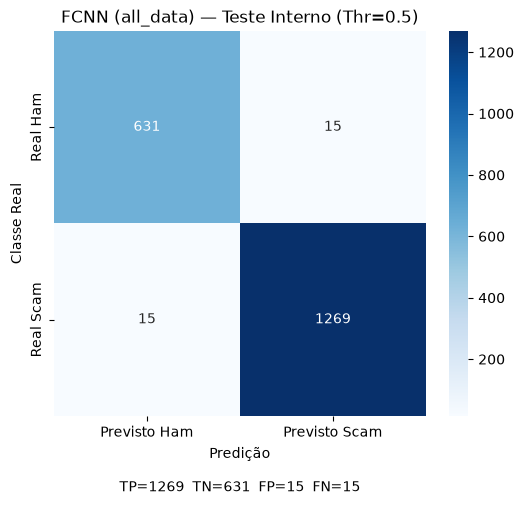

              precision    recall  f1-score   support

     Ham (0)       0.98      0.98      0.98       646
    Scam (1)       0.99      0.99      0.99      1284

    accuracy                           0.98      1930
   macro avg       0.98      0.98      0.98      1930
weighted avg       0.98      0.98      0.98      1930

--- 2) TESTE INTERNO — Threshold Calibrado (Thr=0.021340, FN=0) ---

[Threshold=0.021340] Classification Report:
              precision    recall  f1-score   support

     Ham (0)       1.00      0.86      0.92       646
    Scam (1)       0.93      1.00      0.97      1284

    accuracy                           0.95      1930
   macro avg       0.97      0.93      0.95      1930
weighted avg       0.96      0.95      0.95      1930



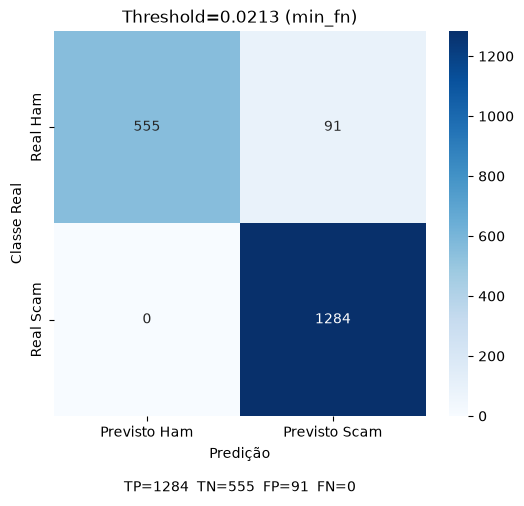

--- 3) VALIDAÇÃO EXTERNA — Threshold Padrão (0.5) ---
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/fcnn/batch_size=200__embedders=voyage_openai__epochs=20__lr=0.001__path_dat_bddd81d9/confusion_matrix.png


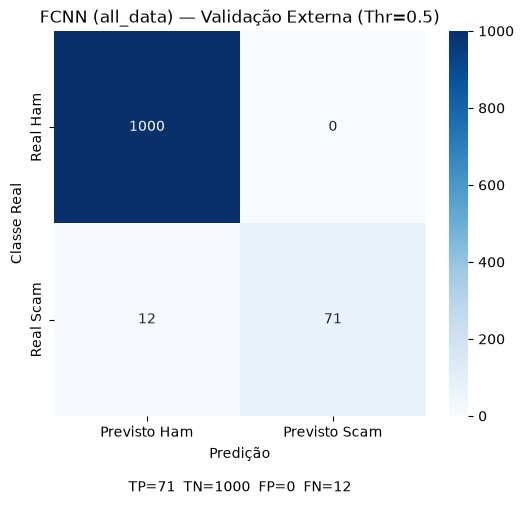

              precision    recall  f1-score   support

     Ham (0)       0.99      1.00      0.99      1000
    Scam (1)       1.00      0.86      0.92        83

    accuracy                           0.99      1083
   macro avg       0.99      0.93      0.96      1083
weighted avg       0.99      0.99      0.99      1083

--- 4) VALIDAÇÃO EXTERNA — Reaplicação do Threshold Calibrado no Teste (0.021340) ---

[Threshold=0.021340] Classification Report:
              precision    recall  f1-score   support

     Ham (0)       1.00      1.00      1.00      1000
    Scam (1)       1.00      1.00      1.00        83

    accuracy                           1.00      1083
   macro avg       1.00      1.00      1.00      1083
weighted avg       1.00      1.00      1.00      1083



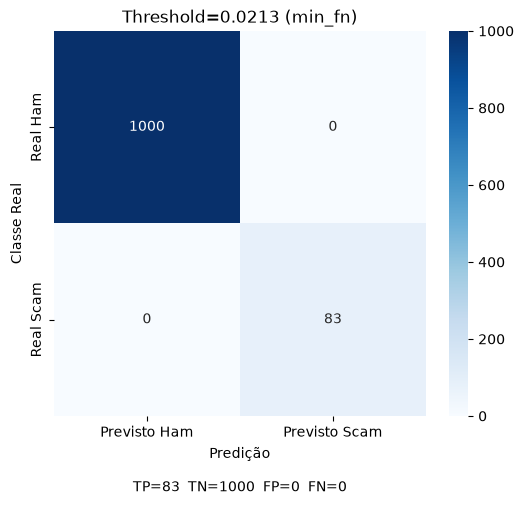

In [12]:
print("=== Calibração de Threshold (Zero-FN) para FCNN (all_data) ===")
# 1. Calibração no Teste Interno (Estratégia min_fn -> FN=0)
cal_all = res_all.calibrate_threshold(strategy="min_fn")
cal_all.plot_fp_fn_tradeoff()
cal_all.plot_precision_recall_curve()
best_thr_all = cal_all.threshold_
print(f"Threshold Calibrado no Teste Interno (Zero-FN): {best_thr_all:.6f}")

# 2. Avaliação no Teste Interno (Threshold 0.5 vs Threshold Calibrado)
print("--- 1) TESTE INTERNO — Threshold Padrão (0.5) ---")
res_all.plot_confusion_matrix(title="FCNN (all_data) — Teste Interno (Thr=0.5)")
res_all.print_classification_report()

print(f"--- 2) TESTE INTERNO — Threshold Calibrado (Thr={best_thr_all:.6f}, FN=0) ---")
cal_all.apply_and_show(res_all.y_true, res_all.y_prob)

# 3. Avaliação na Validação Externa (Threshold 0.5 vs Threshold Calibrado no Teste)
print("--- 3) VALIDAÇÃO EXTERNA — Threshold Padrão (0.5) ---")
val_all.plot_confusion_matrix(title="FCNN (all_data) — Validação Externa (Thr=0.5)")
val_all.print_classification_report()

print(f"--- 4) VALIDAÇÃO EXTERNA — Reaplicação do Threshold Calibrado no Teste ({best_thr_all:.6f}) ---")
cal_all.apply_and_show(val_all.y_true, val_all.y_prob)


=== Calibração de Threshold (Zero-FN) para FCNN (suspect_turns) ===
[ThresholdCalibrator] Estratégia='min_fn' -> threshold=0.028686


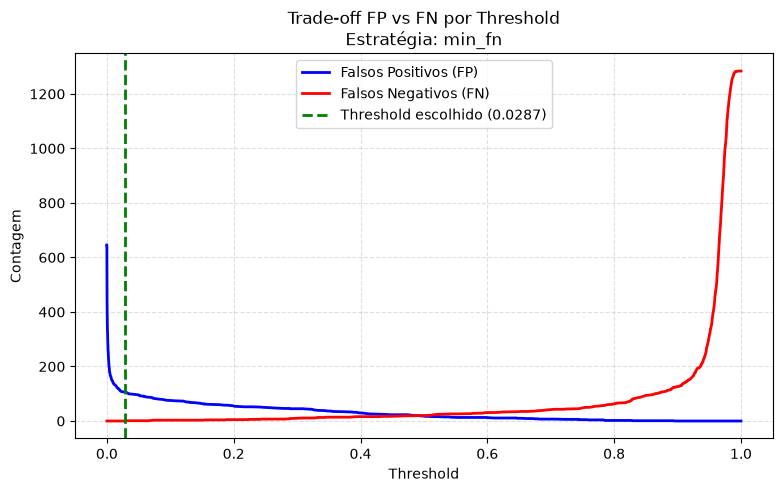

Threshold Calibrado no Teste Interno (Zero-FN): 0.028686
--- 1) TESTE INTERNO — Threshold Padrão (0.5) ---
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/fcnn/batch_size=200__embedders=voyage_openai__epochs=50__lr=1e-05__path_dat_60ff972a/confusion_matrix.png


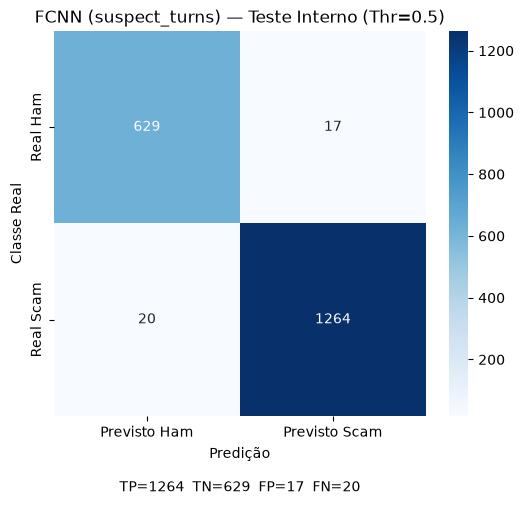

              precision    recall  f1-score   support

     Ham (0)       0.97      0.97      0.97       646
    Scam (1)       0.99      0.98      0.99      1284

    accuracy                           0.98      1930
   macro avg       0.98      0.98      0.98      1930
weighted avg       0.98      0.98      0.98      1930

--- 2) TESTE INTERNO — Threshold Calibrado (Thr=0.028686, FN=0) ---

[Threshold=0.028686] Classification Report:
              precision    recall  f1-score   support

     Ham (0)       1.00      0.84      0.91       646
    Scam (1)       0.92      1.00      0.96      1284

    accuracy                           0.95      1930
   macro avg       0.96      0.92      0.94      1930
weighted avg       0.95      0.95      0.94      1930



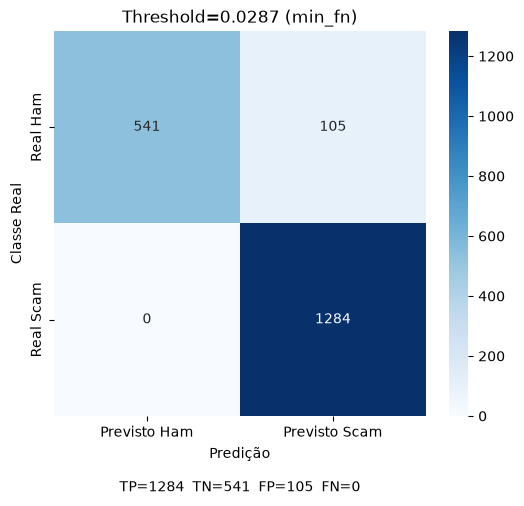

--- 3) VALIDAÇÃO EXTERNA — Threshold Padrão (0.5) ---
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/fcnn/batch_size=200__embedders=voyage_openai__epochs=50__lr=1e-05__path_dat_60ff972a/confusion_matrix.png


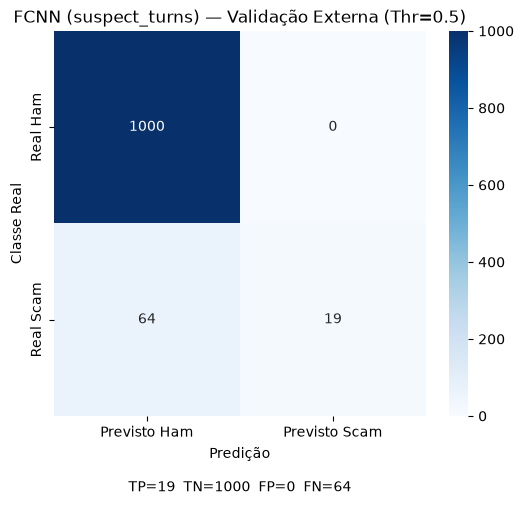

              precision    recall  f1-score   support

     Ham (0)       0.94      1.00      0.97      1000
    Scam (1)       1.00      0.23      0.37        83

    accuracy                           0.94      1083
   macro avg       0.97      0.61      0.67      1083
weighted avg       0.94      0.94      0.92      1083

--- 4) VALIDAÇÃO EXTERNA — Reaplicação do Threshold Calibrado no Teste (0.028686) ---

[Threshold=0.028686] Classification Report:
              precision    recall  f1-score   support

     Ham (0)       0.98      1.00      0.99      1000
    Scam (1)       0.95      0.73      0.83        83

    accuracy                           0.98      1083
   macro avg       0.97      0.87      0.91      1083
weighted avg       0.98      0.98      0.98      1083



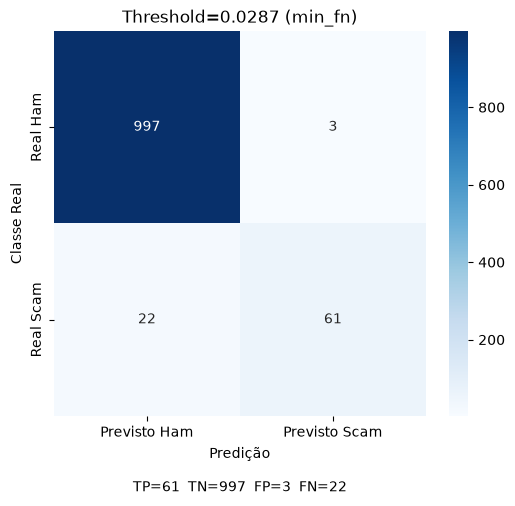

In [13]:
print("=== Calibração de Threshold (Zero-FN) para FCNN (suspect_turns) ===")
# 1. Calibração no Teste Interno (Estratégia min_fn -> FN=0)
cal_suspect = res_suspect.calibrate_threshold(strategy="min_fn")
cal_suspect.plot_fp_fn_tradeoff()
best_thr_suspect = cal_suspect.threshold_
print(f"Threshold Calibrado no Teste Interno (Zero-FN): {best_thr_suspect:.6f}")

# 2. Avaliação no Teste Interno (Threshold 0.5 vs Threshold Calibrado)
print("--- 1) TESTE INTERNO — Threshold Padrão (0.5) ---")
res_suspect.plot_confusion_matrix(title="FCNN (suspect_turns) — Teste Interno (Thr=0.5)")
res_suspect.print_classification_report()

print(f"--- 2) TESTE INTERNO — Threshold Calibrado (Thr={best_thr_suspect:.6f}, FN=0) ---")
cal_suspect.apply_and_show(res_suspect.y_true, res_suspect.y_prob)

# 3. Avaliação na Validação Externa (Threshold 0.5 vs Threshold Calibrado no Teste)
print("--- 3) VALIDAÇÃO EXTERNA — Threshold Padrão (0.5) ---")
val_suspect.plot_confusion_matrix(title="FCNN (suspect_turns) — Validação Externa (Thr=0.5)")
val_suspect.print_classification_report()

print(f"--- 4) VALIDAÇÃO EXTERNA — Reaplicação do Threshold Calibrado no Teste ({best_thr_suspect:.6f}) ---")
cal_suspect.apply_and_show(val_suspect.y_true, val_suspect.y_prob)


## 5. Curva de Aprendizado pelo Tamanho do Dataset (0\%, 25\%, 50\%, 75\%, 100\%$)
Avaliação da estabilidade do modelo em função do percentual de dados de treino utilizados.

In [ ]:
# Curva de aprendizado para Cenário 1 (all_data)
lc_all = learning_curve_fcnn(
    path_data="all_data",
    embedders=EMBEDDERS,
    fractions=[0.10, 0.25, 0.50, 0.75, 1.00],
    epochs=30,
    n_repeats=3,
    with_augmented=WITH_AUGMENTED,
    force_recompute=True
)


[data] Concatenando 2 embeddings: ['voyage', 'openai']
  [data] voyage: voyage_chunks.parquet
    Shape: (9648, 1024)
  [data] openai: openai_chunks.parquet
    Shape: (9648, 3072)
[data] Shape final concatenado: X=(9648, 4096), y=(9648,)
[data] Concatenando 2 embeddings: ['voyage', 'openai']
  [data] voyage: voyage_chunks.parquet
    Shape: (1083, 1024)
  [data] openai: openai_chunks.parquet
    Shape: (1083, 3072)
[data] Shape final concatenado: X=(1083, 4096), y=(1083,)
  [fcnn_lc] frac=10% -> f1=0.9653 | val_f1=0.8367
  [fcnn_lc] frac=25% -> f1=0.9690 | val_f1=0.9362
  [fcnn_lc] frac=50% -> f1=0.9742 | val_f1=0.8662
  [fcnn_lc] frac=75% -> f1=0.9799 | val_f1=0.7905


[data] Concatenando 2 embeddings: ['voyage', 'openai']
  [data] voyage: voyage_chunks.parquet
    Shape: (9648, 1024)
  [data] openai: openai_chunks.parquet
    Shape: (9648, 3072)
[data] Shape final concatenado: X=(9648, 4096), y=(9648,)
[data] Concatenando 2 embeddings: ['voyage', 'openai']
  [data] voyage: voyage_chunks.parquet
    Shape: (1083, 1024)
  [data] openai: openai_chunks.parquet
    Shape: (1083, 3072)
[data] Shape final concatenado: X=(1083, 4096), y=(1083,)
  [fcnn_lc] frac=10% -> f1=0.9666 | val_f1=0.6846
  [fcnn_lc] frac=25% -> f1=0.9746 | val_f1=0.7032
  [fcnn_lc] frac=50% -> f1=0.9808 | val_f1=0.6335
  [fcnn_lc] frac=75% -> f1=0.9815 | val_f1=0.6917
  [fcnn_lc] frac=100% -> f1=0.9806 | val_f1=0.6652
[cache] Histórico salvo: experiment_results/fcnn/lc_embedders='voyage','openai'__fractions=0.1,0.25,0.5,0.75,1.0__path_dat_38d192fa/history.csv
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/fcnn/lc_embedders='voyage','openai'__frac

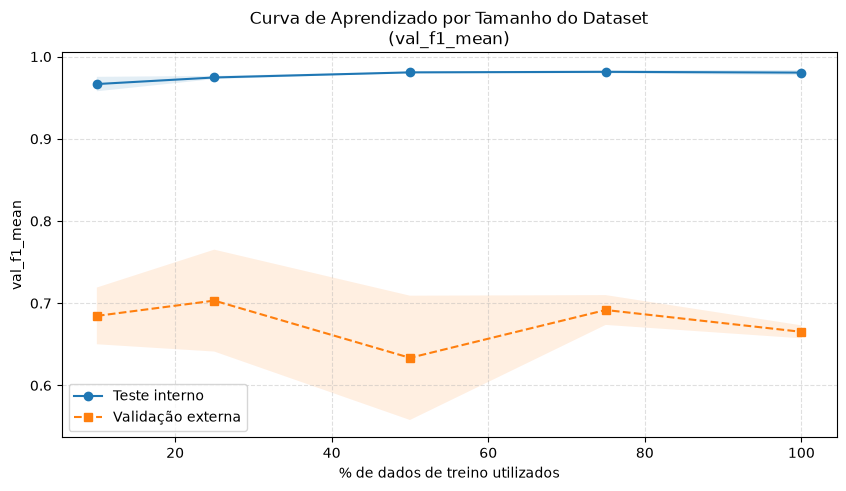

In [ ]:
# Curva de aprendizado para Cenário 2 (suspect_turns)
lc_suspect = learning_curve_fcnn(
    path_data="suspect_turns",
    embedders=EMBEDDERS,
    fractions=[0.10, 0.25, 0.50, 0.75, 1.00],
    epochs=30,
    n_repeats=3,
    with_augmented=WITH_AUGMENTED,
    force_recompute=False
)


## 6. Grid Search de Hiperparâmetros para os 5 Embeddings Concatenados (6.528d)
Busca em grade para otimizar , ,  e Please ask your administrator. mantendo todos os 5 embeddings.
Avalia o impacto na generalização da Validação Externa e na calibração do threshold Zero-FN.

In [ ]:
# Executa o Grid Search sistemático no cenário all_data
df_grid = grid_search_fcnn(
    path_data="all_data",
    embedders=EMBEDDERS,
    with_augmented=WITH_AUGMENTED,
    lrs=[1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 1e-3],
    batch_sizes=[64, 128, 200],
    patiences=[5, 10, 15],
    weight_decays=[1e-4, 1e-3, 1e-2],
    epochs=40,
    force_recompute=False
)

print("=== Top 10 Melhores Configurações Encontradas ===")
df_grid = df_grid.sort_values(by="best_val_f1_train", ascending=False)
display(df_grid.head(10))


[fcnn_grid] Cache hit — grid search (162 combinações)
=== Top 10 Melhores Configurações Encontradas ===


,lr,batch_size,patience,weight_decay,best_val_f1_train,test_f1_macro,zero_fn_threshold,ext_val_f1_05,ext_val_prec_scam_05,ext_val_rec_scam_05,ext_val_f1_cal,ext_val_prec_scam_cal,ext_val_rec_scam_cal
115,0.000010,128,15,0.0001,0.985518,0.985518,0.000754,0.745783,1.0,0.349398,0.613104,0.235795,1.000000
155,0.000030,128,15,0.0001,0.985518,0.985518,0.000057,0.803047,1.0,0.457831,0.317425,0.104271,1.000000
143,0.000100,128,10,0.0010,0.985496,0.985496,0.000153,0.867824,1.0,0.602410,0.461115,0.143599,1.000000
75,0.000010,200,10,0.0010,0.984933,0.984933,0.002060,0.820361,1.0,0.493976,0.832311,0.543046,0.987952
132,0.000010,64,15,0.0010,0.984933,0.984933,0.000573,0.862854,1.0,0.590361,0.542686,0.184035,1.000000
154,0.000030,64,5,0.0010,0.984933,0.984933,0.000083,0.745783,1.0,0.349398,0.326612,0.106003,1.000000
108,0.000003,64,10,0.0001,0.984910,0.984910,0.001791,0.808909,1.0,0.469880,0.634603,0.255385,1.000000
146,0.000010,64,10,0.0100,0.984899,0.984899,0.000528,0.814680,1.0,0.481928,0.405744,0.124812,1.000000
95,0.000010,64,10,0.0001,0.984371,0.984371,0.003477,0.825956,1.0,0.506024,0.740761,0.382488,1.000000
109,0.000003,64,15,0.0100,0.984371,0.984371,0.001750,0.791041,1.0,0.433735,0.628898,0.250000,1.000000


[fcnn_grid] Grid Search Concluído com sucesso!
      lr  batch_size  patience  weight_decay  best_val_f1_train  test_f1_macro  zero_fn_threshold  ext_val_f1_05  ext_val_prec_scam_05  ext_val_rec_scam_05  ext_val_f1_cal  ext_val_prec_scam_cal  ext_val_rec_scam_cal
0.001000         200        10        0.0001           0.980826       0.980826           0.001271       0.836893                   1.0             0.530120        0.987233               0.954023              1.000000
0.001000         200        10        0.0010           0.979075       0.979075           0.080998       0.808909                   1.0             0.469880        0.986806               0.987654              0.963855
0.000100          64         5        0.0010           0.983201       0.983201           0.008055       0.772288                   1.0             0.397590        0.983779               0.964286              0.975904
0.001000          64        10        0.0001           0.981400       0.981400           0.078213       0.896218                   1.0             0.674699        0.983414               0.987500              0.951807
0.001000         128        15        0.0001           0.982549       0.982549           0.010641       0.930669                   1.0             0.771084        0.981054               0.932584              1.000000
0.000030         128         5        0.0100           0.982589       0.982589           0.022692       0.717390                   1.0             0.301205        0.980209               0.975309              0.951807
0.000001         128         5        0.0001           0.974996       0.974996           0.056350       0.759259                   1.0             0.373494        0.980209               0.975309              0.951807
0.000030         128         5        0.0010           0.981414       0.981414           0.040651       0.778641                   1.0             0.409639        0.979984               0.987342              0.939759
0.001000         200        10        0.0100           0.975147       0.975147           0.078368       0.803047                   1.0             0.457831        0.979754               1.000000              0.927711
0.000001         128        15        0.0001           0.973773       0.973773           0.095858       0.759259                   1.0             0.373494        0.979754               1.000000              0.927711
=== Top 10 Melhores Configurações Encontradas ===